# Downstream Analysis: Active vs Passive Learning

This notebook compiles the final segmentation results and runs the downstream selected-example analysis for the combined dataset.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# Setup

!pip install -q tifffile imagecodecs

import sys
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

ROOT = Path("/content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR")
CODE_DIR = ROOT / "FINAL_Codes"
DATA_DIR = CODE_DIR / "data"
OUT_DIR = ROOT / "outputs"

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT exists:", ROOT.exists())
print("CODE_DIR exists:", CODE_DIR.exists())
print("DATA_DIR exists:", DATA_DIR.exists())
print("OUT_DIR exists:", OUT_DIR.exists())


ROOT exists: True
CODE_DIR exists: True
DATA_DIR exists: True
OUT_DIR exists: True


## Final active/passive results

In [14]:
allResults = pd.DataFrame([
    {'dataset': 'BBBC006', 'strategy': 'passive', 'training_samples': 120, 'test_dice': 0.947, 'test_iou': 0.907},
    {'dataset': 'BBBC006', 'strategy': 'active',  'training_samples': 120, 'test_dice': 0.948, 'test_iou': 0.909},
    {'dataset': 'BBBC039', 'strategy': 'passive', 'training_samples': 120, 'test_dice': 0.956, 'test_iou': 0.916},
    {'dataset': 'BBBC039', 'strategy': 'active',  'training_samples': 120, 'test_dice': 0.957, 'test_iou': 0.918},
    {'dataset': 'combined', 'strategy': 'passive', 'training_samples': 120, 'test_dice': 0.573, 'test_iou': 0.502},
    {'dataset': 'combined', 'strategy': 'active',  'training_samples': 120, 'test_dice': 0.623, 'test_iou': 0.547},
])

print(allResults.to_string(index=False))

resultsPath = OUT_DIR / 'downstream_final_active_passive_results.csv'
allResults.to_csv(resultsPath, index=False)
print('Saved:', resultsPath)


 dataset strategy  training_samples  test_dice  test_iou
 BBBC006  passive               120      0.947     0.907
 BBBC006   active               120      0.948     0.909
 BBBC039  passive               120      0.956     0.916
 BBBC039   active               120      0.957     0.918
combined  passive               120      0.573     0.502
combined   active               120      0.623     0.547
Saved: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/downstream_final_active_passive_results.csv


In [15]:
summaryRows = []

for datasetName in allResults['dataset'].unique():
    subset = allResults[allResults['dataset'] == datasetName]
    passiveRow = subset[subset['strategy'] == 'passive'].iloc[0]
    activeRow = subset[subset['strategy'] == 'active'].iloc[0]

    summaryRows.append({
        'dataset': datasetName,
        'passive_dice': passiveRow['test_dice'],
        'active_dice': activeRow['test_dice'],
        'dice_active_minus_passive': activeRow['test_dice'] - passiveRow['test_dice'],
        'passive_iou': passiveRow['test_iou'],
        'active_iou': activeRow['test_iou'],
        'iou_active_minus_passive': activeRow['test_iou'] - passiveRow['test_iou'],
    })

summaryTable = pd.DataFrame(summaryRows)
print(summaryTable.to_string(index=False))

summaryPath = OUT_DIR / 'downstream_active_passive_summary.csv'
summaryTable.to_csv(summaryPath, index=False)
print('Saved:', summaryPath)


 dataset  passive_dice  active_dice  dice_active_minus_passive  passive_iou  active_iou  iou_active_minus_passive
 BBBC006         0.947        0.948                      0.001        0.907       0.909                     0.002
 BBBC039         0.956        0.957                      0.001        0.916       0.918                     0.002
combined         0.573        0.623                      0.050        0.502       0.547                     0.045
Saved: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/downstream_active_passive_summary.csv


## Summary plots

Saved: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/downstream_dice_comparison_across_datasets.png


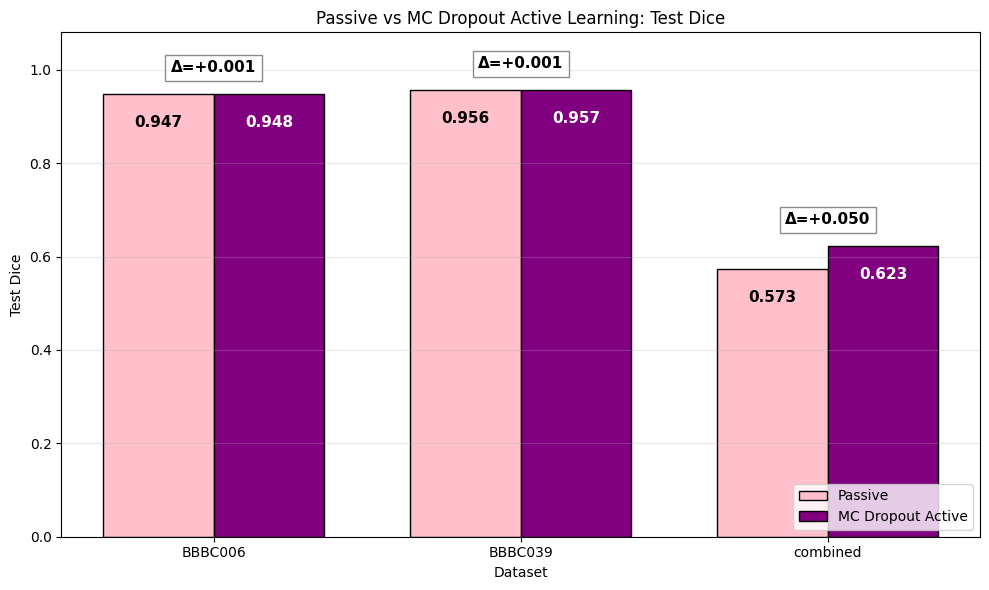

Saved: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/downstream_iou_comparison_across_datasets.png


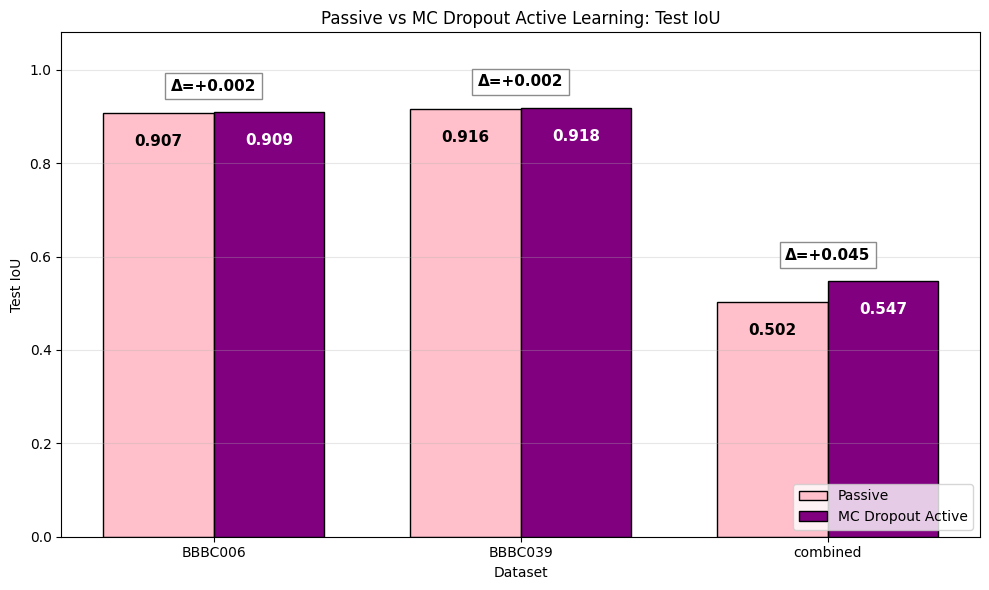

In [16]:
def plotMetricComparison(summaryTable, metricName):
    metricKey = metricName.lower()
    passiveColumn = f'passive_{metricKey}'
    activeColumn = f'active_{metricKey}'
    differenceColumn = f'{metricKey}_active_minus_passive'

    datasets = summaryTable['dataset'].tolist()
    x = np.arange(len(datasets))
    width = 0.36

    passiveValues = summaryTable[passiveColumn].values
    activeValues = summaryTable[activeColumn].values
    differences = summaryTable[differenceColumn].values

    plt.figure(figsize=(10, 6))

    passiveBars = plt.bar(x - width / 2, passiveValues, width, label='Passive', color='pink', edgecolor='black')
    activeBars = plt.bar(x + width / 2, activeValues, width, label='MC Dropout Active', color='purple', edgecolor='black')

    plt.ylabel(f'Test {metricName}')
    plt.xlabel('Dataset')
    plt.title(f'Passive vs MC Dropout Active Learning: Test {metricName}')
    plt.xticks(x, datasets)
    plt.ylim(0, 1.08)
    plt.grid(axis='y', alpha=0.3)
    plt.legend(loc='lower right')

    for bars, textColor in [(passiveBars, 'black'), (activeBars, 'white')]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height - 0.045, f'{height:.3f}',
                     ha='center', va='top', fontsize=11, fontweight='bold', color=textColor)

    for i, difference in enumerate(differences):
        yPosition = max(passiveValues[i], activeValues[i]) + 0.04
        plt.text(x[i], yPosition, f'Δ={difference:+.3f}', ha='center', va='bottom', fontsize=11,
                 fontweight='bold', bbox=dict(facecolor='white', edgecolor='gray', alpha=0.9))

    plt.tight_layout()
    figurePath = OUT_DIR / f'downstream_{metricKey}_comparison_across_datasets.png'
    plt.savefig(figurePath, dpi=300, bbox_inches='tight')
    print('Saved:', figurePath)
    plt.show()

plotMetricComparison(summaryTable, 'Dice')
plotMetricComparison(summaryTable, 'IoU')


## Offline upper-bound plot

Saved: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/combined_offline_upper_bound_dice.png


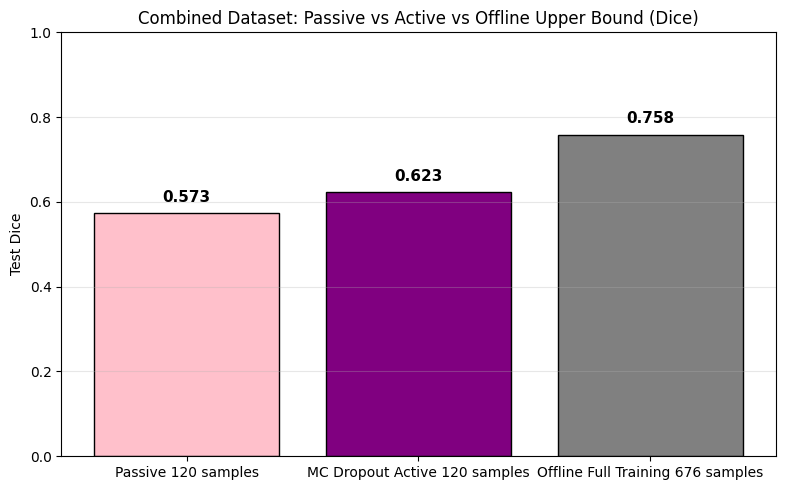

Saved: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/combined_offline_upper_bound_iou.png


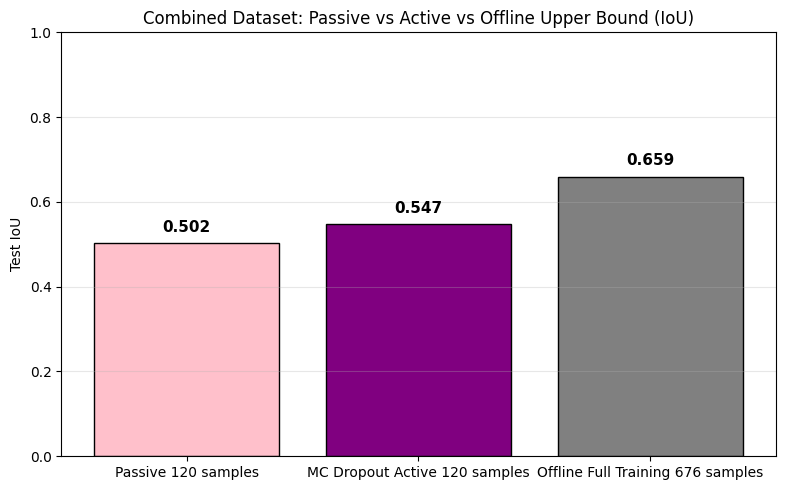

In [17]:
offlineComparisonTable = pd.DataFrame([{'strategy': 'Passive 120 samples', 'test_dice': 0.573, 'test_iou': 0.502}, {'strategy': 'MC Dropout Active 120 samples', 'test_dice': 0.623, 'test_iou': 0.547},
    {'strategy': 'Offline Full Training 676 samples', 'test_dice': 0.758, 'test_iou': 0.659},
])

colors = ['pink', 'purple', 'gray']

for metricColumn, metricName in [('test_dice', 'Dice'), ('test_iou', 'IoU')]:
    plt.figure(figsize=(8, 5))
    bars = plt.bar(offlineComparisonTable['strategy'], offlineComparisonTable[metricColumn], color=colors, edgecolor='black')

    plt.ylabel(f'Test {metricName}')
    plt.title(f'Combined Dataset: Passive vs Active vs Offline Upper Bound ({metricName})')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f'{height:.3f}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    figurePath = OUT_DIR / f'combined_offline_upper_bound_{metricName.lower()}.png'
    plt.savefig(figurePath, dpi=300, bbox_inches='tight')
    print('Saved:', figurePath)
    plt.show()


## Selected-example feature analysis

In [18]:
datasetName = 'combined'
seed = 42

imageDirectory = DATA_DIR / datasetName / 'images'
maskDirectory = DATA_DIR / datasetName / 'masks'

print('Image folder exists:', imageDirectory.exists())
print('Mask folder exists:', maskDirectory.exists())
print('Images:', len(listimgs(imageDirectory)))
print('Masks:', len(listimgs(maskDirectory)))


Image folder exists: True
Mask folder exists: True
Images: 966
Masks: 966


In [19]:
def pairByOrder(imageDirectory, maskDirectory, sourceName):
    imageFiles = listimgs(imageDirectory)
    maskFiles = listimgs(maskDirectory)

    if len(imageFiles) == 0 or len(maskFiles) == 0:
        raise ValueError('No image or mask files found.')

    n = min(len(imageFiles), len(maskFiles))
    rows = []

    for imagePath, maskPath in zip(imageFiles[:n], maskFiles[:n]):
        rows.append({
            'image_id': imagePath.stem,
            'image_path': str(imagePath),
            'mask_path': str(maskPath),
            'source': sourceName
        })

    return pd.DataFrame(rows).reset_index(drop=True)

fullTable = pairByOrder(imageDirectory, maskDirectory, datasetName)

trainingTable, validationTable, testTable = splitData(
    fullTable,
    seed=seed,
    trainSize=0.70,
    validationSize=0.15,
    testSize=0.15
)

print('full table:', len(fullTable))
print('training size:', len(trainingTable))
print('validation size:', len(validationTable))
print('test size:', len(testTable))


full table: 966
training size: 676
validation size: 145
test size: 145


In [21]:
print("Files in OUT_DIR:")

for p in OUT_DIR.iterdir():
    if "index" in p.name.lower() or "selected" in p.name.lower():
        print(p.name)

Files in OUT_DIR:


In [20]:
passiveIndexPath = OUT_DIR / f'{datasetName}_passive_selected_indexes.csv'
activeIndexPath = OUT_DIR / f'{datasetName}_active_selected_indexes.csv'

print('passive index file exists:', passiveIndexPath.exists())
print('active index file exists:', activeIndexPath.exists())

passiveIndexes = pd.read_csv(passiveIndexPath)['index'].tolist()
activeIndexes = pd.read_csv(activeIndexPath)['index'].tolist()

overlap = len(set(passiveIndexes) & set(activeIndexes))

print('passive selected:', len(passiveIndexes))
print('active selected:', len(activeIndexes))
print('overlap:', overlap)
print('overlap fraction:', overlap / len(activeIndexes))

if overlap == len(activeIndexes):
    print('The saved active and passive index files are identical. Resave the active indexes from the experiment notebook before interpreting Figure 5.')


passive index file exists: False
active index file exists: False


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs/combined_passive_selected_indexes.csv'

In [ ]:
def extractImageMaskFeatures(row):
    image = readImage(row['image_path'])
    image = toTwoDimensional(image)
    image = normalizeGray(image)

    mask = readImage(row['mask_path'])
    mask = toTwoDimensional(mask)
    mask = normalizeGray(mask)
    mask = (mask > 0).astype(np.float32)

    labeledMask, objectCount = ndimage.label(mask)

    maskArea = np.sum(mask)
    maskFraction = maskArea / mask.size

    if objectCount > 0:
        objectSizes = ndimage.sum(mask, labeledMask, index=range(1, objectCount + 1))
        meanObjectSize = np.mean(objectSizes)
        medianObjectSize = np.median(objectSizes)
    else:
        meanObjectSize = 0
        medianObjectSize = 0

    return {
        'image_id': row['image_id'],
        'source': row['source'],
        'mean_intensity': float(np.mean(image)),
        'std_intensity': float(np.std(image)),
        'mask_fraction': float(maskFraction),
        'mask_area_pixels': float(maskArea),
        'object_count': int(objectCount),
        'mean_object_size': float(meanObjectSize),
        'median_object_size': float(medianObjectSize),
    }

def buildSelectedFeatureTable(trainingTable, selectedIndexes, strategyName):
    rows = []
    for index in selectedIndexes:
        row = trainingTable.iloc[index]
        features = extractImageMaskFeatures(row)
        features['selected_index'] = index
        features['strategy'] = strategyName
        rows.append(features)
    return pd.DataFrame(rows)

passiveFeatureTable = buildSelectedFeatureTable(trainingTable, passiveIndexes, 'passive')
activeFeatureTable = buildSelectedFeatureTable(trainingTable, activeIndexes, 'active')
selectedFeatureTable = pd.concat([passiveFeatureTable, activeFeatureTable], ignore_index=True)

print(selectedFeatureTable.head())


In [ ]:
featureColumns = [
    'mean_intensity',
    'std_intensity',
    'mask_fraction',
    'object_count',
    'mean_object_size'
]

featureSummary = selectedFeatureTable.groupby('strategy')[featureColumns].mean()

print(featureSummary)

featureSummaryPath = OUT_DIR / f'{datasetName}_selected_example_feature_summary.csv'
selectedFeaturePath = OUT_DIR / f'{datasetName}_selected_example_features.csv'

featureSummary.to_csv(featureSummaryPath)
selectedFeatureTable.to_csv(selectedFeaturePath, index=False)

print('Saved:', featureSummaryPath)
print('Saved:', selectedFeaturePath)


In [ ]:
featureLabels = {
    'mean_intensity': 'Mean intensity
(signal brightness)',
    'std_intensity': 'Intensity variation
(background/contrast)',
    'mask_fraction': 'Mask fraction
(foreground coverage)',
    'object_count': 'Object count
(crowding)',
    'mean_object_size': 'Mean object size
(cell/nucleus size)'
}

featureMeans = selectedFeatureTable.groupby('strategy')[featureColumns].mean()

differenceValues = featureMeans.loc['active', featureColumns] - featureMeans.loc['passive', featureColumns]
relativeDifference = differenceValues / featureMeans.loc['passive', featureColumns]

plt.figure(figsize=(12, 5))

bars = plt.bar(
    [featureLabels[feature] for feature in featureColumns],
    relativeDifference.values,
    color='purple',
    edgecolor='black'
)

plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Relative difference
(active - passive) / passive')
plt.title('Figure 5. Active vs Passive Selected-Example Feature Analysis')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:+.1%}',
        ha='center',
        va='bottom' if height >= 0 else 'top',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
figurePath = OUT_DIR / f'{datasetName}_figure5_selected_feature_analysis.png'
plt.savefig(figurePath, dpi=300, bbox_inches='tight')
print('Saved:', figurePath)
plt.show()
